In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpdaf.obj import Cube
from astropy.coordinates import SkyCoord
import sys
import os
import plotfancy as pf
from matplotlib.patches import Circle, ConnectionPatch, FancyArrowPatch, Arrow
from astropy.visualization import ZScaleInterval

from types import SimpleNamespace
import re
from astropy.io import ascii, fits
from astropy import units as u
from astropy.constants import c as speedoflight
from astropy.table import Table, vstack, hstack, join
from scipy.optimize import curve_fit, root
from astropy.cosmology import Planck18 as cosmo
from astropy import coordinates as coords
from astroquery.sdss import SDSS
from requests.exceptions import ConnectionError
from matplotlib.lines import Line2D
# from hst_phot import *
from prospect.models.templates import TemplateLibrary
from prospect.models import SpecModel
import prospect.fitting as fitting
from prospect.io import write_results as writer
import prospect.io.read_results as reader
from prospect.sources import CSPSpecBasis
from prospect.models import priors
from genesis_metallicity.genesis_metallicity import genesis_metallicity
from mpl_toolkits.axes_grid1.inset_locator import mark_inset, zoomed_inset_axes

# from calculate_jiang19_metallicity import calculate_metallicity_jiang19 as cjm19
sys.path.append('../../../')
import src.ifu_tools.line_ratios as lr
import src.ifu_tools.ifutools as ift

import logging 
logging.getLogger('mpdaf').setLevel(logging.WARNING)

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [37]:
# massmet_old = Table(ascii.read('massmet_old.csv'))
# massmet_old['new'] = 0
# massmet_new = Table(ascii.read('massmet_new.csv'))
# massmet_new['new'] = 1

# massmet_all = vstack([massmet_old,massmet_new])
# massmet_all.write('massmet_all.csv')
massmet_all = Table(ascii.read('massmet_all.csv'))

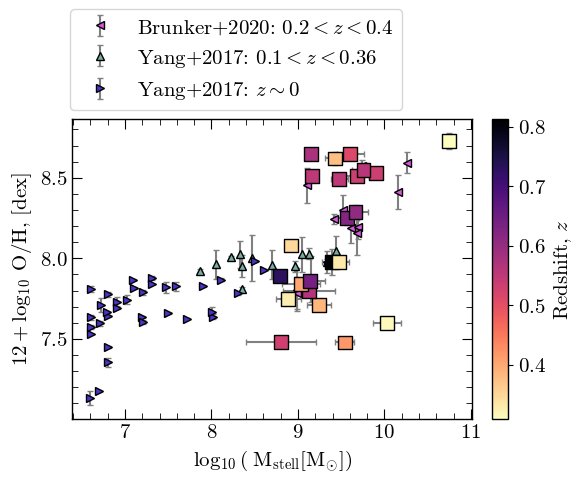

In [80]:
fig, ax = pf.create_plot()

ax.set_ylabel(r'$12+\log_{10}\;$O/H, [dex]')
ax.set_xlabel(r'$\log_{10}(\;\mathrm{M}_{\mathrm{stell}} [\mathrm{M}_{\odot}])$')

colors = ['#77aca2', '#ff004f']
shape = ['o','s']

eelgs_only = massmet_all[massmet_all['eelg']==1]

cmap = ax.scatter(eelgs_only['logmstellar'], eelgs_only['zdir'], c=eelgs_only['z'],edgecolor='k', marker=shape[i], s=100, zorder=10, cmap='magma_r')
ax.errorbar(eelgs_only['logmstellar'], eelgs_only['zdir'],xerr=eelgs_only['merror'], yerr=eelgs_only['zerror'], ecolor='gray', capsize=2, color='none', zorder=-10)

brunkerPeas = ascii.read('../cigale_analysis/brunkerPeas.csv')
# ax.scatter(brunkerPeas['x'], brunkerPeas['y'], color="#d856db", marker='<', label=r'Brunker+2020: $0.2<z<0.4$', edgecolors='k')

ax.errorbar(brunkerPeas['x'], brunkerPeas['y'], mfc="#d856db", fmt='<', 
            label=r'Brunker+2020: $0.2<z<0.4$', mec='k', yerr=np.abs(np.random.normal(0,0.08,size=len(brunkerPeas['y']))),
            ecolor='grey', capsize=2)

yangBlues = ascii.read('../cigale_analysis/yangPs.csv')
# ax.scatter(yangBlues['x'], yangBlues['y'], color="#77aca2", marker='^', label=r'Yang+2017: $0.1<z<0.36$', edgecolors='k')

ax.errorbar(yangBlues['x'], yangBlues['y'], mfc="#77aca2", fmt='^', 
            label=r'Yang+2017: $0.1<z<0.36$', mec='k', yerr=np.abs(np.random.normal(0,0.08,size=len(yangBlues['y']))),
            ecolor='grey', capsize=2)

yangPeas = ascii.read('../cigale_analysis/yangBlues.csv')
# ax.scatter(yangPeas['x'], yangPeas['y'], color="#4c33c8", marker='>', label=r'Yang+2017: $z\sim0$', edgecolors='k')

ax.errorbar(yangPeas['x'], yangPeas['y'], mfc="#4c33c8", fmt='>', 
            label=r'Yang+2017: $z\sim0$', mec='k', yerr=np.abs(np.random.normal(0,0.02,size=len(yangPeas['y']))),
            ecolor='grey', capsize=2)

cax = fig.add_axes((1.05,0,0.04,1))
plt.colorbar(cmap, cax=cax, label='Redshift, $z$')

ax.legend(bbox_to_anchor=(0.85, 1.4))

pf.fix_plot([ax])
fig.savefig(f'figs/massmet_EELGs.png', dpi=600, bbox_inches='tight')

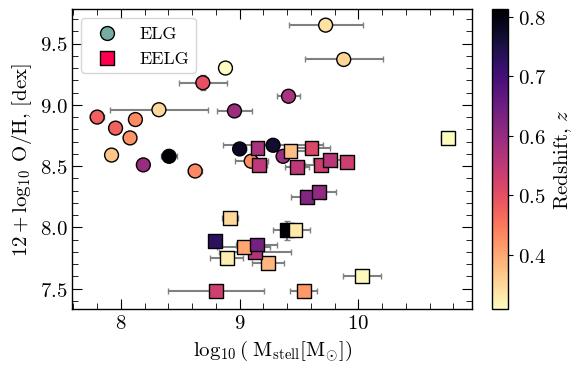

In [72]:
fig, ax = pf.create_plot()

ax.scatter(massmet_all['logmstellar'], massmet_all['zdir'])

ax.set_ylabel(r'$12+\log_{10}\;$O/H, [dex]')
ax.set_xlabel(r'$\log_{10}(\;\mathrm{M}_{\mathrm{stell}} [\mathrm{M}_{\odot}])$')

colors = ['#77aca2', '#ff004f']
shape = ['o','s']
labels = ['ELG','EELG']

for i in range(2):
    subtable = massmet_all[massmet_all['eelg']==i]
    cmap = ax.scatter(subtable['logmstellar'], subtable['zdir'], c=subtable['z'],edgecolor='k', marker=shape[i], s=100, cmap='magma_r')
    ax.errorbar(subtable['logmstellar'], subtable['zdir'],xerr=subtable['merror'], yerr=subtable['zerror'], ecolor='gray', capsize=2, color='none', zorder=-10)
    ax.scatter([0,0],[0,0],edgecolor='k', marker=shape[i], s=100, label=labels[i], color=colors[i])

cax = fig.add_axes((1.05,0,0.04,1))

ax.set_xlim(7.589418649528188,10.958185722242032)
ax.set_ylim(7.333749999999972,9.78124999999992)

plt.colorbar(cmap, cax=cax, label='Redshift, $z$')

ax.legend(loc='upper left', fontsize=13)

pf.fix_plot([ax])
fig.savefig(f'figs/massmet_new.png', dpi=600, bbox_inches='tight')

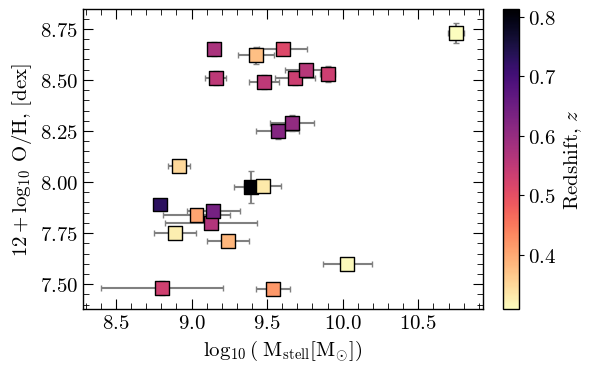

In [83]:
fig, ax = pf.create_plot()

cmap = ax.scatter(eelgs_only['logmstellar'], eelgs_only['zdir'], c=eelgs_only['z'],edgecolor='k', marker=shape[i], s=100, zorder=10, cmap='magma_r')
ax.errorbar(eelgs_only['logmstellar'], eelgs_only['zdir'],xerr=eelgs_only['merror'], yerr=eelgs_only['zerror'], ecolor='gray', capsize=2, color='none', zorder=-10)

ax.set_ylabel(r'$12+\log_{10}\;$O/H, [dex]')
ax.set_xlabel(r'$\log_{10}(\;\mathrm{M}_{\mathrm{stell}} [\mathrm{M}_{\odot}])$')

colors = ['#77aca2', '#ff004f']
shape = ['o','s']

eelgs_only = massmet_all[massmet_all['eelg']==1]

cax = fig.add_axes((1.05,0,0.04,1))
plt.colorbar(cmap, cax=cax, label='Redshift, $z$')

# ax.legend(bbox_to_anchor=(0.85, 1.4))

pf.fix_plot([ax])
fig.savefig(f'figs/massmet_EELGs_nosurvey.png', dpi=600, bbox_inches='tight')